In [2]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import sys
print(sys.executable)

c:\Users\sreea\anaconda3\python.exe


In [4]:
import sys
!{sys.executable} -m pip install psycopg2-binary

In [5]:
import psycopg2

print("psycopg2 installed successfully!")

psycopg2 installed successfully!


In [6]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

password = "Jagan7nathan&"

DATABASE_URL = (
    f"postgresql+psycopg2://postgres:{quote_plus(password)}"
    "@localhost:5432/pricepilot_ai"
)

engine = create_engine(DATABASE_URL)

with engine.connect() as connection:
    print("Database connection successful!")

Database connection successful!


In [7]:
import pandas as pd
query = """
SELECT *
FROM pricing_demand
"""

df = pd.read_sql(query, engine)

print("Data loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Data loaded successfully!
Rows: 172800
Columns: 18


,id,date,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,32069,2026-01-29,P1119,Apparel,Under Armour,UK,app,Winter,197.31,197.31,0.0,0.0,None,18,3551.58,295,False,113.21
1,32072,2026-02-01,P1119,Apparel,Under Armour,UK,web,Winter,197.31,197.31,0.0,0.0,None,9,1775.79,287,False,56.60
2,32073,2026-02-02,P1119,Apparel,Under Armour,UK,web,Winter,197.31,197.31,0.0,0.0,None,8,1578.48,181,False,50.31
3,32074,2026-02-03,P1119,Apparel,Under Armour,UK,mobile,Winter,197.31,197.31,0.0,0.0,None,14,2762.34,291,False,88.05
4,32076,2026-02-05,P1119,Apparel,Under Armour,UK,mobile,Winter,197.31,197.31,0.0,0.0,None,18,3551.58,139,False,113.21


In [8]:
query = """
SELECT *
FROM pricing_demand
"""

df = pd.read_sql(query, engine)

print("Data loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Data loaded successfully!
Rows: 172800
Columns: 18


,id,date,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,32069,2026-01-29,P1119,Apparel,Under Armour,UK,app,Winter,197.31,197.31,0.0,0.0,None,18,3551.58,295,False,113.21
1,32072,2026-02-01,P1119,Apparel,Under Armour,UK,web,Winter,197.31,197.31,0.0,0.0,None,9,1775.79,287,False,56.60
2,32073,2026-02-02,P1119,Apparel,Under Armour,UK,web,Winter,197.31,197.31,0.0,0.0,None,8,1578.48,181,False,50.31
3,32074,2026-02-03,P1119,Apparel,Under Armour,UK,mobile,Winter,197.31,197.31,0.0,0.0,None,14,2762.34,291,False,88.05
4,32076,2026-02-05,P1119,Apparel,Under Armour,UK,mobile,Winter,197.31,197.31,0.0,0.0,None,18,3551.58,139,False,113.21


In [9]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (172800, 18)

Data types:
id                    int64
date                 object
product_id           object
category             object
brand                object
region               object
channel              object
season               object
base_price          float64
current_price       float64
price_change_pct    float64
discount_pct        float64
promotion_type       object
units_sold            int64
revenue             float64
inventory_level       int64
stockout_flag          bool
demand_index        float64
dtype: object

Missing values:
id                       0
date                     0
product_id               0
category                 0
brand                    0
region                   0
channel                  0
season                   0
base_price               0
current_price            0
price_change_pct         0
discount_pct             0
promotion_type      100155
units_sold               0
revenue                  0
inventory_level          0


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,172800.0,NaN,NaN,NaN,86400.5,49883.207595,1.0,43200.75,86400.5,129600.25,172800.0
date,172800,90,2026-01-29,1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,172800,640,P1119,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,172800,8,Apparel,21600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,172800,33,Nike,18090,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,172800,6,IN,30690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,172800,3,web,57703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,172800,2,Winter,113280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
base_price,172800.0,NaN,NaN,NaN,221.370656,125.659903,8.55,112.3025,217.325,326.2775,449.74
current_price,172800.0,NaN,NaN,NaN,197.82836,118.293731,4.28,97.16,188.96,287.96,449.74


In [11]:
print("Categories:")
print(df["category"].unique())

print("\nBrands:")
print(df["brand"].nunique())

print("\nRegions:")
print(df["region"].unique())

print("\nChannels:")
print(df["channel"].unique())

print("\nSeasons:")
print(df["season"].unique())

print("\nPromotion types:")
print(df["promotion_type"].unique())

Categories:
['Apparel' 'Beauty' 'Accessories' 'Electronics' 'Home' 'Groceries'
 'Sports' 'Shoes']

Brands:
33

Regions:
['UK' 'DE' 'US' 'AU' 'CA' 'IN']

Channels:
['app' 'web' 'mobile']

Seasons:
['Winter' 'Spring']

Promotion types:
[None 'Buy One Get One' 'Member Offer' 'Percentage Discount' 'Flash Sale'
 'Clearance']


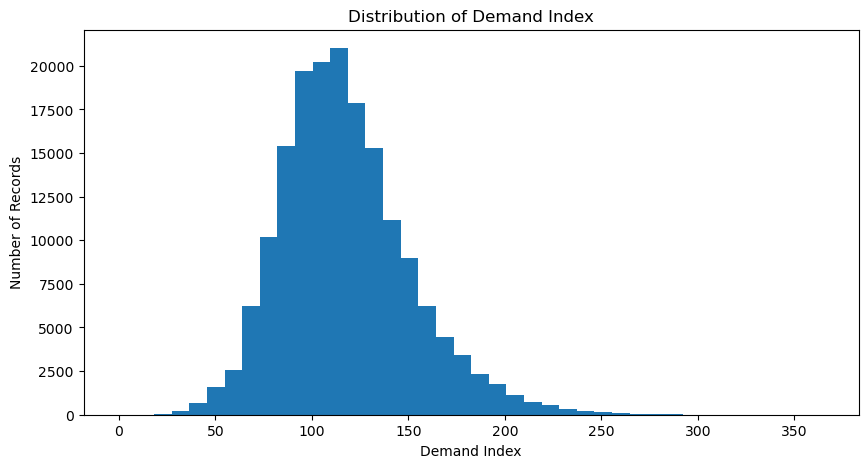

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["demand_index"], bins=40)

plt.xlabel("Demand Index")
plt.ylabel("Number of Records")
plt.title("Distribution of Demand Index")

plt.show()

In [13]:
print("Demand Index Statistics")
print("-----------------------")
print(f"Mean   : {df['demand_index'].mean():.2f}")
print(f"Median : {df['demand_index'].median():.2f}")
print(f"Min    : {df['demand_index'].min():.2f}")
print(f"Max    : {df['demand_index'].max():.2f}")

Demand Index Statistics
-----------------------
Mean   : 117.44
Median : 113.64
Min    : 0.00
Max    : 365.08


In [14]:
print(
    df[
        [
            "current_price",
            "discount_pct",
            "units_sold",
            "inventory_level",
            "demand_index"
        ]
    ].corr()["demand_index"].sort_values(ascending=False)
)

demand_index       1.000000
units_sold         0.569887
discount_pct       0.532910
inventory_level   -0.057531
current_price     -0.142502
Name: demand_index, dtype: float64


In [15]:
model_df = df.drop(
    columns=[
        "id",
        "units_sold",
        "revenue"
    ]
).copy()

print("Original shape:", df.shape)
print("ML dataset shape:", model_df.shape)

model_df.head()

Original shape: (172800, 18)
ML dataset shape: (172800, 15)


,date,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,inventory_level,stockout_flag,demand_index
0,2026-01-29,P1119,Apparel,Under Armour,UK,app,Winter,197.31,197.31,0.0,0.0,None,295,False,113.21
1,2026-02-01,P1119,Apparel,Under Armour,UK,web,Winter,197.31,197.31,0.0,0.0,None,287,False,56.60
2,2026-02-02,P1119,Apparel,Under Armour,UK,web,Winter,197.31,197.31,0.0,0.0,None,181,False,50.31
3,2026-02-03,P1119,Apparel,Under Armour,UK,mobile,Winter,197.31,197.31,0.0,0.0,None,291,False,88.05
4,2026-02-05,P1119,Apparel,Under Armour,UK,mobile,Winter,197.31,197.31,0.0,0.0,None,139,False,113.21


In [16]:
print(model_df.columns.tolist())

['date', 'product_id', 'category', 'brand', 'region', 'channel', 'season', 'base_price', 'current_price', 'price_change_pct', 'discount_pct', 'promotion_type', 'inventory_level', 'stockout_flag', 'demand_index']


In [17]:
model_df["date"] = pd.to_datetime(model_df["date"])

model_df["year"] = model_df["date"].dt.year
model_df["month"] = model_df["date"].dt.month
model_df["day"] = model_df["date"].dt.day
model_df["day_of_week"] = model_df["date"].dt.dayofweek

model_df = model_df.drop(columns=["date"])

print(model_df.shape)
model_df.head()

(172800, 18)


,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,inventory_level,stockout_flag,demand_index,year,month,day,day_of_week
0,P1119,Apparel,Under Armour,UK,app,Winter,197.31,197.31,0.0,0.0,None,295,False,113.21,2026,1,29,3
1,P1119,Apparel,Under Armour,UK,web,Winter,197.31,197.31,0.0,0.0,None,287,False,56.60,2026,2,1,6
2,P1119,Apparel,Under Armour,UK,web,Winter,197.31,197.31,0.0,0.0,None,181,False,50.31,2026,2,2,0
3,P1119,Apparel,Under Armour,UK,mobile,Winter,197.31,197.31,0.0,0.0,None,291,False,88.05,2026,2,3,1
4,P1119,Apparel,Under Armour,UK,mobile,Winter,197.31,197.31,0.0,0.0,None,139,False,113.21,2026,2,5,3


In [18]:
X = model_df.drop(columns=["demand_index"])
y = model_df["demand_index"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (172800, 17)
y shape: (172800,)

Features:
['product_id', 'category', 'brand', 'region', 'channel', 'season', 'base_price', 'current_price', 'price_change_pct', 'discount_pct', 'promotion_type', 'inventory_level', 'stockout_flag', 'year', 'month', 'day', 'day_of_week']

Target:
demand_index


In [19]:
categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['product_id', 'category', 'brand', 'region', 'channel', 'season', 'promotion_type', 'stockout_flag']

Numerical features:
['base_price', 'current_price', 'price_change_pct', 'discount_pct', 'inventory_level']


In [20]:
print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Minimum date: 2026-01-01
Maximum date: 2026-03-31


In [21]:
df["date"] = pd.to_datetime(df["date"])

split_date = df["date"].quantile(0.8)

print("Train/Test split date:", split_date)

Train/Test split date: 2026-03-13 04:48:00.000001024


In [22]:

df["date"] = pd.to_datetime(df["date"])

# Split date
split_date = df["date"].quantile(0.8)

# Create train and test masks
train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

# Use the same feature columns we already identified
X_train = model_df.loc[train_mask].drop(columns=["demand_index"])
X_test = model_df.loc[test_mask].drop(columns=["demand_index"])

y_train = model_df.loc[train_mask, "demand_index"]
y_test = model_df.loc[test_mask, "demand_index"]

print("Training data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nSplit date:", split_date)

Training data:
X_train shape: (138240, 17)
y_train shape: (138240,)

Testing data:
X_test shape: (34560, 17)
y_test shape: (34560,)

Split date: 2026-03-13 04:48:00.000001024


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Categorical features
categorical_features = [
    "product_id",
    "category",
    "brand",
    "region",
    "channel",
    "season",
    "promotion_type",
    "stockout_flag"
]

# Numerical features
numerical_features = [
    "base_price",
    "current_price",
    "price_change_pct",
    "discount_pct",
    "inventory_level",
    "year",
    "month",
    "day",
    "day_of_week"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")
print("\nNumerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

Preprocessor created successfully!

Numerical features: ['base_price', 'current_price', 'price_change_pct', 'discount_pct', 'inventory_level', 'year', 'month', 'day', 'day_of_week']

Categorical features: ['product_id', 'category', 'brand', 'region', 'channel', 'season', 'promotion_type', 'stockout_flag']


In [24]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (138240, 709)
Processed X_test shape: (34560, 709)


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Model libraries imported successfully!")

Model libraries imported successfully!


In [26]:
# Linear Regression model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train_processed, y_train)

# Predict
lr_predictions = lr_model.predict(X_test_processed)

# Evaluate
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE  :", lr_mae)
print("RMSE :", lr_rmse)
print("R²   :", lr_r2)

Linear Regression Results
-------------------------
MAE  : 19.91061869685421
RMSE : 25.32357078719482
R²   : 0.38462872371364876


In [27]:
# Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train_processed, y_train)

print("Random Forest training completed!")

# Predictions
rf_predictions = rf_model.predict(X_test_processed)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("\nRandom Forest Results")
print("--------------------")
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)
print("R²   :", rf_r2)

Training Random Forest...
Random Forest training completed!

Random Forest Results
--------------------
MAE  : 20.45781162110944
RMSE : 26.201470777030135
R²   : 0.341222627612911


In [28]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [29]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [30]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost training completed!")

# Predictions
xgb_predictions = xgb_model.predict(X_test_processed)

# Evaluation
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("\nXGBoost Results")
print("----------------")
print("MAE  :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R²   :", xgb_r2)

Training XGBoost...
XGBoost training completed!

XGBoost Results
----------------
MAE  : 20.01896042406559
RMSE : 25.552300103127454
R²   : 0.3734621221463621


In [31]:
print("Actual demand_index statistics:")
print(y_test.describe())

print("\nPredicted demand_index statistics:")
print(pd.Series(lr_predictions).describe())

Actual demand_index statistics:
count    34560.000000
mean       112.169414
std         32.282162
min          0.000000
25%         90.910000
50%        108.530000
75%        129.630000
max        300.490000
Name: demand_index, dtype: float64

Predicted demand_index statistics:
count    34560.000000
mean       111.980191
std         20.849255
min         62.072452
25%         96.688967
50%        107.579631
75%        125.983634
max        182.188749
dtype: float64


In [32]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_predictions
})

print(comparison_df.head(10))

   Actual   Predicted
0  119.50  110.405838
1   81.76  102.692223
2  100.63  108.899790
3  169.81  108.500927
4   94.34  108.470655
5  113.21   90.709479
6  100.63   89.916246
7  144.65  108.473529
8   75.47  109.142933
9   88.05   91.481140


In [33]:
print("\nPrediction error statistics:")
errors = y_test.values - lr_predictions

print("Mean Error :", errors.mean())
print("Min Error  :", errors.min())
print("Max Error  :", errors.max())


Prediction error statistics:
Mean Error : 0.1892228876075297
Min Error  : -110.73427996068682
Max Error  : 143.19426247325606


In [34]:
print(df.columns.tolist())

['id', 'date', 'product_id', 'category', 'brand', 'region', 'channel', 'season', 'base_price', 'current_price', 'price_change_pct', 'discount_pct', 'promotion_type', 'units_sold', 'revenue', 'inventory_level', 'stockout_flag', 'demand_index']


In [35]:
print(
    df[["demand_index", "units_sold"]].head(10)
)

   demand_index  units_sold
0        113.21          18
1         56.60           9
2         50.31           8
3         88.05          14
4        113.21          18
5        132.08          21
6        100.63          16
7        100.63          16
8        106.92          17
9        150.94          24


In [36]:
print("Lowest demand records:")
print(
    df[["date", "demand_index", "units_sold", "discount_pct",
        "current_price", "inventory_level"]]
    .sort_values("demand_index")
    .head(10)
)

print("\nHighest demand records:")
print(
    df[["date", "demand_index", "units_sold", "discount_pct",
        "current_price", "inventory_level"]]
    .sort_values("demand_index", ascending=False)
    .head(10)
)

Lowest demand records:
             date  demand_index  units_sold  discount_pct  current_price  \
64098  2026-02-13          0.00           0           0.0         374.37   
35926  2026-02-05          0.00           0           0.0         222.27   
47616  2026-02-06          0.00           0           0.0         297.62   
52848  2026-03-27          0.00           0           0.0         215.09   
64240  2026-01-14          0.00           0           0.0         267.84   
162687 2026-02-23          0.00           0           0.0         125.92   
2050   2026-03-29          0.00           0           0.0         230.39   
99901  2026-01-05          0.00           0           5.0         371.60   
67743  2026-02-17          0.00           0           0.0         414.06   
4872   2026-03-03         12.35           1           0.0         406.93   

        inventory_level  
64098               256  
35926               415  
47616               369  
52848               333  
64240     

In [37]:
print(model_df.head())

  product_id category         brand region channel  season  base_price  \
0      P1119  Apparel  Under Armour     UK     app  Winter      197.31   
1      P1119  Apparel  Under Armour     UK     web  Winter      197.31   
2      P1119  Apparel  Under Armour     UK     web  Winter      197.31   
3      P1119  Apparel  Under Armour     UK  mobile  Winter      197.31   
4      P1119  Apparel  Under Armour     UK  mobile  Winter      197.31   

   current_price  price_change_pct  discount_pct promotion_type  \
0         197.31               0.0           0.0           None   
1         197.31               0.0           0.0           None   
2         197.31               0.0           0.0           None   
3         197.31               0.0           0.0           None   
4         197.31               0.0           0.0           None   

   inventory_level  stockout_flag  demand_index  year  month  day  day_of_week  
0              295          False        113.21  2026      1   29      

In [38]:
print(df[["units_sold", "demand_index"]].corr())

              units_sold  demand_index
units_sold      1.000000      0.569887
demand_index    0.569887      1.000000


In [39]:
print(
    df.groupby("units_sold")["demand_index"]
      .agg(["count", "min", "max", "mean"])
      .head(20)
)

            count    min     max        mean
units_sold                                  
0               9   0.00    0.00    0.000000
1            1049  12.35   50.00   43.874490
2            5999  16.00  100.00   78.233364
3            8209  20.27  150.00   98.785422
4            7459  18.87  200.00  105.999536
5            6983  23.70  238.10  105.565743
6            7083  27.78  285.71  105.591872
7            7138  32.41  250.00  107.087390
8            7097  37.91  285.71  108.361966
9            7152  41.10  290.32  108.895344
10           7355  45.87  333.33  109.046337
11           7403  50.23  250.00  109.790426
12           7497  54.79  272.73  109.928165
13           7518  59.36  270.83  111.644738
14           7544  63.93  285.71  112.945773
15           7251  68.49  258.62  114.220554
16           7128  73.06  296.30  116.072549
17           6882  77.63  303.57  117.677085
18           6668  82.19  264.71  120.435793
19           6107  86.76  260.27  123.345422


In [40]:
print(
    df[["units_sold", "demand_index"]]
    .sort_values("units_sold", ascending=False)
    .head(20)
)

        units_sold  demand_index
139862          69        365.08
128057          69        316.51
103997          65        300.93
128043          64        293.58
122175          61        279.82
91284           61        289.10
128046          61        279.82
118001          61        300.49
89489           60        277.78
128085          59        270.64
84632           59        324.18
112128          57        275.36
89452           57        263.89
124431          56        258.06
117989          56        275.86
117570          56        256.88
128095          56        256.88
89848           56        255.71
152247          56        255.71
122140          56        256.88


In [41]:
print(df[["date", "product_id", "units_sold", "demand_index"]]
      .sort_values(["product_id", "date"])
      .head(20))

             date product_id  units_sold  demand_index
81483  2026-01-01      P1001          15        133.93
81521  2026-01-01      P1001          10         89.29
154234 2026-01-01      P1001          13        116.07
123522 2026-01-02      P1001          10         89.29
154181 2026-01-02      P1001          13        116.07
154235 2026-01-02      P1001          13        116.07
81522  2026-01-03      P1001          11         98.21
81558  2026-01-03      P1001          15        133.93
123523 2026-01-03      P1001          13        116.07
81484  2026-01-04      P1001          13        116.07
154182 2026-01-04      P1001          13        116.07
154236 2026-01-04      P1001          16        142.86
81523  2026-01-05      P1001          15        133.93
81559  2026-01-05      P1001          15        133.93
123524 2026-01-05      P1001          13        116.07
81560  2026-01-06      P1001          14        125.00
123525 2026-01-06      P1001          14        125.00
154183 202

In [42]:
print("Number of unique products:", df["product_id"].nunique())
print("Number of dates:", df["date"].nunique())

Number of unique products: 640
Number of dates: 90


In [43]:
print(
    df[df["product_id"] == "P1001"]
    [["date", "product_id", "region", "channel",
      "season", "promotion_type", "units_sold"]]
    .head(20)
)

            date product_id region channel  season       promotion_type  \
81483 2026-01-01      P1001     AU  mobile  Winter      Buy One Get One   
81484 2026-01-04      P1001     AU     web  Winter         Member Offer   
81485 2026-01-08      P1001     AU     web  Winter  Percentage Discount   
81486 2026-01-11      P1001     AU     app  Winter  Percentage Discount   
81487 2026-01-13      P1001     AU     web  Winter  Percentage Discount   
81488 2026-01-15      P1001     AU  mobile  Winter           Flash Sale   
81489 2026-01-17      P1001     AU     web  Winter      Buy One Get One   
81490 2026-01-19      P1001     AU     web  Winter           Flash Sale   
81491 2026-01-21      P1001     AU     app  Winter           Flash Sale   
81492 2026-01-22      P1001     AU  mobile  Winter  Percentage Discount   
81493 2026-01-24      P1001     AU     web  Winter         Member Offer   
81494 2026-01-25      P1001     AU     app  Winter      Buy One Get One   
81495 2026-01-26      P10

In [44]:
print(
    df.groupby(["product_id", "date"]).size().value_counts()
)

3    57600
Name: count, dtype: int64


In [45]:
print(
    df.groupby(["product_id", "date"])["channel"]
      .nunique()
      .value_counts()
)

channel
2    38518
3    12678
1     6404
Name: count, dtype: int64


In [46]:
df_lag = df.copy()

df_lag["date"] = pd.to_datetime(df_lag["date"])

df_lag = df_lag.sort_values(
    ["product_id", "channel", "date"]
).reset_index(drop=True)

print("df_lag shape:", df_lag.shape)

df_lag shape: (172800, 18)


In [47]:
# Historical sales features
group_cols = ["product_id", "channel"]

df_lag["units_sold_lag_1"] = (
    df_lag.groupby(group_cols)["units_sold"].shift(1)
)

df_lag["units_sold_lag_7"] = (
    df_lag.groupby(group_cols)["units_sold"].shift(7)
)

df_lag["units_sold_lag_14"] = (
    df_lag.groupby(group_cols)["units_sold"].shift(14)
)

# Rolling averages — shift first to prevent current-day leakage
df_lag["units_sold_rolling_7"] = (
    df_lag.groupby(group_cols)["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df_lag["units_sold_rolling_14"] = (
    df_lag.groupby(group_cols)["units_sold"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

print(
    df_lag[
        [
            "product_id",
            "channel",
            "date",
            "units_sold",
            "units_sold_lag_1",
            "units_sold_lag_7",
            "units_sold_lag_14",
            "units_sold_rolling_7",
            "units_sold_rolling_14"
        ]
    ].head(20)
)

   product_id channel       date  units_sold  units_sold_lag_1  \
0       P1001     app 2026-01-03          15               NaN   
1       P1001     app 2026-01-03          13              15.0   
2       P1001     app 2026-01-04          16              13.0   
3       P1001     app 2026-01-05          15              16.0   
4       P1001     app 2026-01-05          13              15.0   
5       P1001     app 2026-01-06          14              13.0   
6       P1001     app 2026-01-07          10              14.0   
7       P1001     app 2026-01-09          12              10.0   
8       P1001     app 2026-01-11          12              12.0   
9       P1001     app 2026-01-11          16              12.0   
10      P1001     app 2026-01-13          18              16.0   
11      P1001     app 2026-01-16          12              18.0   
12      P1001     app 2026-01-17           8              12.0   
13      P1001     app 2026-01-18           9               8.0   
14      P1

In [48]:
print(
    df_lag[
        [
            "units_sold",
            "units_sold_lag_1",
            "units_sold_lag_7",
            "units_sold_lag_14",
            "units_sold_rolling_7",
            "units_sold_rolling_14"
        ]
    ].describe()
)

          units_sold  units_sold_lag_1  units_sold_lag_7  units_sold_lag_14  \
count  172800.000000     170880.000000     159360.000000      145920.000000   
mean       14.120735         14.126925         14.171097          14.232066   
std         8.344558          8.348843          8.368466           8.400053   
min         0.000000          0.000000          0.000000           0.000000   
25%         7.000000          7.000000          7.000000           7.000000   
50%        13.000000         13.000000         13.000000          13.000000   
75%        20.000000         20.000000         20.000000          20.000000   
max        69.000000         69.000000         69.000000          69.000000   

       units_sold_rolling_7  units_sold_rolling_14  
count         159360.000000          145920.000000  
mean              14.138607              14.150818  
std                7.401597               7.321384  
min                1.000000               1.285714  
25%                7.85

In [49]:
print(
    df[df["product_id"].eq("P1001") & df["channel"].eq("app")]
    [
        [
            "date",
            "product_id",
            "channel",
            "region",
            "season",
            "promotion_type",
            "base_price",
            "current_price",
            "discount_pct",
            "inventory_level",
            "units_sold",
            "demand_index"
        ]
    ]
    .head(20)
)

            date product_id channel region  season       promotion_type  \
81486 2026-01-11      P1001     app     AU  Winter  Percentage Discount   
81491 2026-01-21      P1001     app     AU  Winter           Flash Sale   
81494 2026-01-25      P1001     app     AU  Winter      Buy One Get One   
81495 2026-01-26      P1001     app     AU  Winter            Clearance   
81496 2026-01-28      P1001     app     AU  Winter           Flash Sale   
81499 2026-02-05      P1001     app     AU  Winter         Member Offer   
81500 2026-02-06      P1001     app     AU  Winter         Member Offer   
81502 2026-02-13      P1001     app     AU  Winter           Flash Sale   
81504 2026-02-19      P1001     app     AU  Winter  Percentage Discount   
81505 2026-02-20      P1001     app     AU  Winter  Percentage Discount   
81506 2026-02-22      P1001     app     AU  Winter           Flash Sale   
81507 2026-02-25      P1001     app     AU  Winter  Percentage Discount   
81514 2026-03-19      P10

In [50]:
duplicate_counts = (
    df.groupby(["product_id", "channel", "date"])
      .size()
      .value_counts()
      .sort_index()
)

print(duplicate_counts)

1    76552
2    38518
3     6404
Name: count, dtype: int64


In [51]:
duplicate_check = (
    df.groupby(["product_id", "region", "channel", "date"])
      .size()
      .value_counts()
      .sort_index()
)

print(duplicate_check)

1    172800
Name: count, dtype: int64


In [52]:
df_lag = df.copy()

df_lag["date"] = pd.to_datetime(df_lag["date"])

group_cols = ["product_id", "region", "channel"]

df_lag = df_lag.sort_values(
    group_cols + ["date"]
).reset_index(drop=True)

print("df_lag shape:", df_lag.shape)

df_lag shape: (172800, 18)


In [53]:
# Create a previous-date lookup
historical_sales = df_lag[
    group_cols + ["date", "units_sold"]
].copy()

historical_sales["date"] = historical_sales["date"] + pd.Timedelta(days=1)

historical_sales = historical_sales.rename(
    columns={"units_sold": "units_sold_lag_1"}
)

# Merge yesterday's sales
df_lag = df_lag.merge(
    historical_sales,
    on=group_cols + ["date"],
    how="left"
)

print("Previous-day sales feature created!")

Previous-day sales feature created!


In [54]:
# 7-day lag
lag_7 = df_lag[
    group_cols + ["date", "units_sold"]
].copy()

lag_7["date"] = lag_7["date"] + pd.Timedelta(days=7)

lag_7 = lag_7.rename(
    columns={"units_sold": "units_sold_lag_7"}
)

df_lag = df_lag.merge(
    lag_7,
    on=group_cols + ["date"],
    how="left"
)

# 14-day lag
lag_14 = df_lag[
    group_cols + ["date", "units_sold"]
].copy()

lag_14["date"] = lag_14["date"] + pd.Timedelta(days=14)

lag_14 = lag_14.rename(
    columns={"units_sold": "units_sold_lag_14"}
)

df_lag = df_lag.merge(
    lag_14,
    on=group_cols + ["date"],
    how="left"
)

print("7-day and 14-day lag features created!")

7-day and 14-day lag features created!


In [55]:
print(
    df_lag[
        [
            "product_id",
            "region",
            "channel",
            "date",
            "units_sold",
            "units_sold_lag_1",
            "units_sold_lag_7",
            "units_sold_lag_14"
        ]
    ].head(20)
)

   product_id region channel       date  units_sold  units_sold_lag_1  \
0       P1001     AU     app 2026-01-03          13               NaN   
1       P1001     AU     app 2026-01-05          13               NaN   
2       P1001     AU     app 2026-01-11          12               NaN   
3       P1001     AU     app 2026-01-16          12               NaN   
4       P1001     AU     app 2026-01-18           9               NaN   
5       P1001     AU     app 2026-01-21          15               NaN   
6       P1001     AU     app 2026-01-25          15               NaN   
7       P1001     AU     app 2026-01-26          16              15.0   
8       P1001     AU     app 2026-01-27           9              16.0   
9       P1001     AU     app 2026-01-28          13               9.0   
10      P1001     AU     app 2026-02-02          11               NaN   
11      P1001     AU     app 2026-02-05          12               NaN   
12      P1001     AU     app 2026-02-06          16

In [56]:
print("\nMissing values:")
print(
    df_lag[
        [
            "units_sold_lag_1",
            "units_sold_lag_7",
            "units_sold_lag_14"
        ]
    ].isna().sum()
)


Missing values:
units_sold_lag_1     115709
units_sold_lag_7     119654
units_sold_lag_14    124193
dtype: int64


In [57]:
# Sort correctly
df_lag = df_lag.sort_values(
    group_cols + ["date"]
).reset_index(drop=True)

# Previous observed sales
df_lag["sales_rolling_3"] = (
    df_lag.groupby(group_cols)["units_sold"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

df_lag["sales_rolling_7"] = (
    df_lag.groupby(group_cols)["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

df_lag["sales_rolling_14"] = (
    df_lag.groupby(group_cols)["units_sold"]
    .transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
)

print("Rolling historical sales features created!")

Rolling historical sales features created!


In [58]:
print(
    df_lag[
        [
            "units_sold",
            "sales_rolling_3",
            "sales_rolling_7",
            "sales_rolling_14"
        ]
    ].describe()
)

          units_sold  sales_rolling_3  sales_rolling_7  sales_rolling_14
count  172800.000000    167040.000000    167040.000000     167040.000000
mean       14.120735        14.175757        14.243034         14.335381
std         8.344558         7.676721         7.516497          7.495042
min         0.000000         0.666667         1.000000          1.000000
25%         7.000000         7.666667         8.000000          8.000000
50%        13.000000        14.000000        14.142857         14.285714
75%        20.000000        19.666667        20.000000         20.071429
max        69.000000        55.000000        55.000000         55.000000


In [59]:
# Features to add to our original model features
historical_features = [
    "sales_rolling_3",
    "sales_rolling_7",
    "sales_rolling_14"
]

# Create improved dataframe
model_df_improved = df_lag.copy()

# Remove rows where historical features cannot be calculated
model_df_improved = model_df_improved.dropna(
    subset=historical_features
).reset_index(drop=True)

print("Original rows:", len(df_lag))
print("Improved ML rows:", len(model_df_improved))
print("Rows removed:", len(df_lag) - len(model_df_improved))

print("\nMissing historical features:")
print(
    model_df_improved[historical_features].isna().sum()
)

Original rows: 172800
Improved ML rows: 167040
Rows removed: 5760

Missing historical features:
sales_rolling_3     0
sales_rolling_7     0
sales_rolling_14    0
dtype: int64


In [60]:
print(
    model_df_improved[
        [
            "demand_index",
            "sales_rolling_3",
            "sales_rolling_7",
            "sales_rolling_14"
        ]
    ].corr()["demand_index"].sort_values(ascending=False)
)

demand_index        1.000000
sales_rolling_7     0.158094
sales_rolling_14    0.157629
sales_rolling_3     0.156299
Name: demand_index, dtype: float64


In [61]:
# Make sure date is datetime
model_df_improved["date"] = pd.to_datetime(model_df_improved["date"])

# Create date-based features
model_df_improved["year"] = model_df_improved["date"].dt.year
model_df_improved["month"] = model_df_improved["date"].dt.month
model_df_improved["day"] = model_df_improved["date"].dt.day
model_df_improved["day_of_week"] = model_df_improved["date"].dt.dayofweek

print("Date features created successfully!")

print(
    model_df_improved[
        ["date", "year", "month", "day", "day_of_week"]
    ].head()
)

Date features created successfully!
        date  year  month  day  day_of_week
0 2026-01-05  2026      1    5            0
1 2026-01-11  2026      1   11            6
2 2026-01-16  2026      1   16            4
3 2026-01-18  2026      1   18            6
4 2026-01-21  2026      1   21            2


In [62]:
improved_features = [
    "product_id",
    "category",
    "brand",
    "region",
    "channel",
    "season",
    "base_price",
    "current_price",
    "price_change_pct",
    "discount_pct",
    "promotion_type",
    "inventory_level",
    "stockout_flag",
    "year",
    "month",
    "day",
    "day_of_week",
    "sales_rolling_3",
    "sales_rolling_7",
    "sales_rolling_14"
]

X_improved = model_df_improved[improved_features]
y_improved = model_df_improved["demand_index"]

print("X_improved shape:", X_improved.shape)
print("y_improved shape:", y_improved.shape)

X_improved shape: (167040, 20)
y_improved shape: (167040,)


In [63]:
split_date_improved = model_df_improved["date"].quantile(0.8)

train_mask = model_df_improved["date"] <= split_date_improved

X_train_improved = X_improved[train_mask]
X_test_improved = X_improved[~train_mask]

y_train_improved = y_improved[train_mask]
y_test_improved = y_improved[~train_mask]

print("Training data:")
print("X_train:", X_train_improved.shape)
print("y_train:", y_train_improved.shape)

print("\nTesting data:")
print("X_test:", X_test_improved.shape)
print("y_test:", y_test_improved.shape)

print("\nSplit date:", split_date_improved)

Training data:
X_train: (134400, 20)
y_train: (134400,)

Testing data:
X_test: (32640, 20)
y_test: (32640,)

Split date: 2026-03-14 00:00:00


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features_improved = [
    "product_id",
    "category",
    "brand",
    "region",
    "channel",
    "season",
    "promotion_type",
    "stockout_flag"
]

numerical_features_improved = [
    "base_price",
    "current_price",
    "price_change_pct",
    "discount_pct",
    "inventory_level",
    "year",
    "month",
    "day",
    "day_of_week",
    "sales_rolling_3",
    "sales_rolling_7",
    "sales_rolling_14"
]

preprocessor_improved = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_improved
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features_improved
        )
    ]
)

print("Improved preprocessor created successfully!")

Improved preprocessor created successfully!


In [65]:
X_train_improved_processed = preprocessor_improved.fit_transform(
    X_train_improved
)

X_test_improved_processed = preprocessor_improved.transform(
    X_test_improved
)

print("Processed X_train shape:", X_train_improved_processed.shape)
print("Processed X_test shape:", X_test_improved_processed.shape)

Processed X_train shape: (134400, 712)
Processed X_test shape: (32640, 712)


In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Training Improved Linear Regression...")

lr_improved = LinearRegression()

lr_improved.fit(
    X_train_improved_processed,
    y_train_improved
)

print("Improved Linear Regression training completed!")

Training Improved Linear Regression...
Improved Linear Regression training completed!


In [67]:
y_pred_lr_improved = lr_improved.predict(
    X_test_improved_processed
)

mae_lr_improved = mean_absolute_error(
    y_test_improved,
    y_pred_lr_improved
)

rmse_lr_improved = np.sqrt(
    mean_squared_error(
        y_test_improved,
        y_pred_lr_improved
    )
)

r2_lr_improved = r2_score(
    y_test_improved,
    y_pred_lr_improved
)

print("\nImproved Linear Regression Results")
print("----------------------------------")
print("MAE  :", mae_lr_improved)
print("RMSE :", rmse_lr_improved)
print("R²   :", r2_lr_improved)


Improved Linear Regression Results
----------------------------------
MAE  : 19.94886855523159
RMSE : 25.367813817399732
R²   : 0.3843999293273591


In [68]:
xgb_improved = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("Training Improved XGBoost...")

xgb_improved.fit(
    X_train_improved_processed,
    y_train_improved
)

print("Improved XGBoost training completed!")

Training Improved XGBoost...
Improved XGBoost training completed!


In [69]:
y_pred_xgb_improved = xgb_improved.predict(
    X_test_improved_processed
)

mae_xgb_improved = mean_absolute_error(
    y_test_improved,
    y_pred_xgb_improved
)

rmse_xgb_improved = np.sqrt(
    mean_squared_error(
        y_test_improved,
        y_pred_xgb_improved
    )
)

r2_xgb_improved = r2_score(
    y_test_improved,
    y_pred_xgb_improved
)

print("\nImproved XGBoost Results")
print("------------------------")
print("MAE  :", mae_xgb_improved)
print("RMSE :", rmse_xgb_improved)
print("R²   :", r2_xgb_improved)


Improved XGBoost Results
------------------------
MAE  : 19.855321892252157
RMSE : 25.31865943982323
R²   : 0.3867832739993846


In [70]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Improved Linear Regression",
        "Improved XGBoost"
    ],
    "MAE": [
        19.9106175583431,
        20.443069058615006,
        20.02922088469841,
        mae_lr_improved,
        mae_xgb_improved
    ],
    "RMSE": [
        25.32356959996547,
        26.18160876365439,
        25.563709671418508,
        rmse_lr_improved,
        rmse_xgb_improved
    ],
    "R2": [
        0.3846287814137914,
        0.3422210208472919,
        0.3729024760362851,
        r2_lr_improved,
        r2_xgb_improved
    ]
})

print(model_comparison)

                        Model        MAE       RMSE        R2
0           Linear Regression  19.910618  25.323570  0.384629
1               Random Forest  20.443069  26.181609  0.342221
2                     XGBoost  20.029221  25.563710  0.372902
3  Improved Linear Regression  19.948869  25.367814  0.384400
4            Improved XGBoost  19.855322  25.318659  0.386783


In [71]:
best_model = model_comparison.loc[
    model_comparison["R2"].idxmax()
]

print("\nBest Model:")
print(best_model)


Best Model:
Model    Improved XGBoost
MAE             19.855322
RMSE            25.318659
R2               0.386783
Name: 4, dtype: object


In [72]:
y_pred_final = xgb_improved.predict(
    X_test_improved_processed
)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_final))

Predictions generated successfully!
Number of predictions: 32640


In [73]:
comparison_df = pd.DataFrame({
    "Actual": y_test_improved.values,
    "Predicted": y_pred_final
})

print(comparison_df.head(10))

   Actual   Predicted
0  116.07  108.159264
1  133.93  108.112465
2   53.57  134.223877
3  196.43  163.925552
4  142.86  151.654175
5  116.07  108.243980
6  133.93  105.729034
7  116.07  120.477882
8  116.07  146.321884
9  116.07  101.297371


In [74]:
comparison_df["Error"] = (
    comparison_df["Actual"] -
    comparison_df["Predicted"]
)

comparison_df["Absolute_Error"] = (
    comparison_df["Error"].abs()
)

print("\nPrediction Error Statistics:")
print(comparison_df["Error"].describe())

print("\nMean Absolute Error:")
print(comparison_df["Absolute_Error"].mean())


Prediction Error Statistics:
count    32640.000000
mean        -0.067570
std         25.318957
min       -111.535428
25%        -16.562640
50%         -0.111470
75%         16.099004
max        146.610987
Name: Error, dtype: float64

Mean Absolute Error:
19.855321892252157


In [75]:
print("Actual demand statistics:")
print(comparison_df["Actual"].describe())

print("\nPredicted demand statistics:")
print(comparison_df["Predicted"].describe())

Actual demand statistics:
count    32640.000000
mean       112.176947
std         32.332580
min          0.000000
25%         90.910000
50%        108.530000
75%        129.630000
max        300.490000
Name: Actual, dtype: float64

Predicted demand statistics:
count    32640.000000
mean       112.244514
std         19.297001
min         64.189568
25%         97.346754
50%        107.299191
75%        124.970900
max        214.536469
Name: Predicted, dtype: float64


In [76]:
feature_names = preprocessor_improved.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("Number of model features:", len(xgb_improved.feature_importances_))

Number of feature names: 712
Number of model features: 712


In [77]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_improved.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 Most Important Features:")
print(feature_importance_df.head(20))

Top 20 Most Important Features:
                  Feature  Importance
0   num__price_change_pct    0.075582
1       num__discount_pct    0.059002
2        cat__channel_web    0.029226
3        cat__channel_app    0.019896
4     cat__channel_mobile    0.006186
5      cat__season_Spring    0.005279
6   cat__product_id_P1167    0.004837
7   cat__product_id_P1487    0.004786
8   cat__product_id_P1037    0.004381
9         cat__brand_Puma    0.004186
10  cat__product_id_P1054    0.004119
11  cat__product_id_P1361    0.004057
12  cat__product_id_P1601    0.004042
13  cat__product_id_P1252    0.003985
14  cat__product_id_P1296    0.003877
15       cat__brand_Coach    0.003864
16  cat__product_id_P1514    0.003844
17  cat__product_id_P1173    0.003705
18  cat__product_id_P1013    0.003689
19  cat__product_id_P1619    0.003667


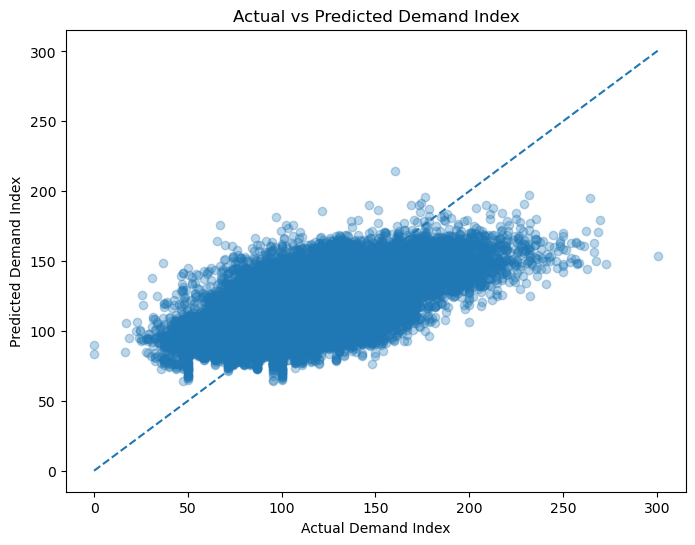

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["Actual"],
    comparison_df["Predicted"],
    alpha=0.3
)

# Perfect prediction line
min_value = min(
    comparison_df["Actual"].min(),
    comparison_df["Predicted"].min()
)

max_value = max(
    comparison_df["Actual"].max(),
    comparison_df["Predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Demand Index")
plt.ylabel("Predicted Demand Index")
plt.title("Actual vs Predicted Demand Index")

plt.show()

In [79]:
import os
import joblib

# Create model directory
model_dir = "../backend/app/ml/demand_forecasting"
os.makedirs(model_dir, exist_ok=True)

# Save the trained Improved XGBoost model
joblib.dump(
    xgb_improved,
    os.path.join(model_dir, "xgb_demand_model.joblib")
)

# Save the preprocessing pipeline
joblib.dump(
    preprocessor_improved,
    os.path.join(model_dir, "demand_preprocessor.joblib")
)

print("Model and preprocessing pipeline saved successfully!")

Model and preprocessing pipeline saved successfully!


In [80]:
import os
import joblib

# Path to the demand forecasting model directory
model_dir = "../backend/app/ml/demand_forecasting"

# Create directory if it does not exist
os.makedirs(model_dir, exist_ok=True)

# Save the trained Improved XGBoost model
model_path = os.path.join(
    model_dir,
    "xgb_demand_model.joblib"
)

joblib.dump(
    xgb_improved,
    model_path
)

# Save the preprocessing pipeline
preprocessor_path = os.path.join(
    model_dir,
    "demand_preprocessor.joblib"
)

joblib.dump(
    preprocessor_improved,
    preprocessor_path
)

print("======================================")
print("MODEL SAVING COMPLETED")
print("======================================")
print("Model saved to:")
print(model_path)
print()
print("Preprocessor saved to:")
print(preprocessor_path)

MODEL SAVING COMPLETED
Model saved to:
../backend/app/ml/demand_forecasting\xgb_demand_model.joblib

Preprocessor saved to:
../backend/app/ml/demand_forecasting\demand_preprocessor.joblib


In [81]:
print(preprocessor_improved)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['base_price', 'current_price',
                                  'price_change_pct', 'discount_pct',
                                  'inventory_level', 'year', 'month', 'day',
                                  'day_of_week', 'sales_rolling_3',
                                  'sales_rolling_7', 'sales_rolling_14']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['product_id', 'category', 'brand', 'region',
                                  'channel', 'season', 'promotion_type',
                                  'stockout_flag'])])


In [82]:
print("Feature columns:")
print(feature_columns_improved)

Feature columns:


NameError: name 'feature_columns_improved' is not defined

In [83]:
print("Categorical columns:")
print(categorical_features_improved)

print("\nNumerical columns:")
print(numerical_features_improved)

Categorical columns:
['product_id', 'category', 'brand', 'region', 'channel', 'season', 'promotion_type', 'stockout_flag']

Numerical columns:
['base_price', 'current_price', 'price_change_pct', 'discount_pct', 'inventory_level', 'year', 'month', 'day', 'day_of_week', 'sales_rolling_3', 'sales_rolling_7', 'sales_rolling_14']
